<a href="https://colab.research.google.com/github/thekylebell/Correlated-Multi-Asset-Monte-Carlo-Simulation/blob/main/Time_Series_Template_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This notebook serves as a template for building Time Series Momentum models. We will build the model step by step, explaining what each step achieves and why it is necessary.

A Time-series momentum (or Absolute Momentum) is a simple model that follows market trends. It does not compare itself to other assets, only how it is performing relative to its past. The core idea is that if the model shows positive growth over the specified time period (e.g., 3 months or 12 months), then you buy it. If it is negative, you exit or go to cash. You are betting that the price trend will continue.




A Time-Series model consists of four essential components.

The first is the Lookback Period (N). This is the timeframe used to determine the trend. Common quant benchmarks are 126 days (6 months) or 252 days (1 year).

The second component is The Signal: A binary output (1 -> Long, 0 -> Cash), or buy/sell. This comes in the form: Long -> Current Price > Price N days ago ; Cash -> Current Price < Price N days ago.

The third component is the Holding Period. This is how often you re-evaluate. Most momentum models rebalance monthly to avoid over-trading and false signals.

The fourth component is the Benchmark. An asset to compare performance against, usually a 3-month T-Bill or simply 0% (cash).


The inputs for the model are even simpler. There is one primary data point: Adjusted Closing Price. The reason for using adjusted is to account for dividends and stock splits. This is to prevent our "momentum" being a divdend payout looking like a price drop.

Frequency: Daily data is best for calculation, even if you only trade monthly (Holding Period).

Lets build the Model!

In [2]:
#Start by importing the libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


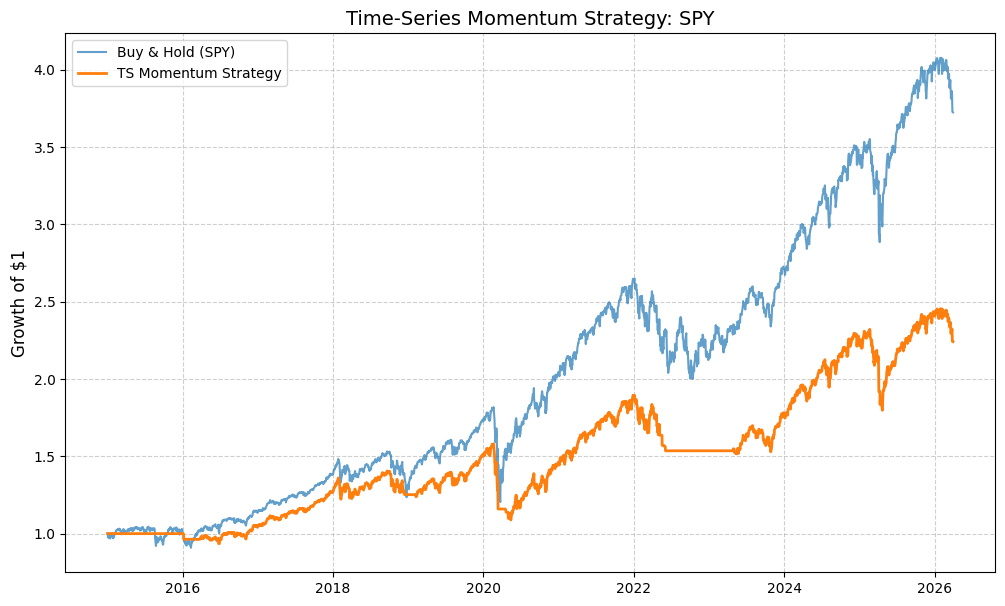

Total Strategy Return: 124.14%


In [6]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
ticker = 'SPY'
lookback_days = 252  # 1 year of trading days
start_date = '2015-01-01'

# --- 2. DATA ACQUISITION ---
# auto_adjust=False ensures we get the 'Adj Close' column explicitly
df = yf.download(ticker, start=start_date, auto_adjust=False)

# Flatten MultiIndex (yfinance 2026 fix)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep only the adjusted close price and make a copy to avoid warnings
df = df[['Adj Close']].copy()

# --- 3. MODEL LOGIC ---
# Momentum: (Current Price / Price N days ago) - 1
df['momentum'] = (df['Adj Close'] / df['Adj Close'].shift(lookback_days)) - 1

# Signal: 1 (Long) if momentum > 0, else 0 (Cash)
df['signal'] = (df['momentum'] > 0).astype(int)

# Lagging: Shift the signal by 1 day to prevent look-ahead bias
# You trade TODAY'S return based on YESTERDAY'S momentum signal
df['position'] = df['signal'].shift(1)

# --- 4. PERFORMANCE CALCULATION ---
# Daily benchmark returns
df['benchmark_return'] = df['Adj Close'].pct_change()

# Strategy returns = Benchmark Return * Your Position (0 or 1)
df['strategy_return'] = df['benchmark_return'] * df['position']

# --- 5. VISUALIZATION ---
# Growth of $1 (Cumulative Product)
# We fill NaN with 0 for the first return to start at exactly 1.0
performance = (1 + df[['benchmark_return', 'strategy_return']].fillna(0)).cumprod()

plt.figure(figsize=(12, 7))
plt.plot(performance['benchmark_return'], label='Buy & Hold (SPY)', alpha=0.7)
plt.plot(performance['strategy_return'], label='TS Momentum Strategy', linewidth=2)
plt.title(f"Time-Series Momentum Strategy: {ticker}", fontsize=14)
plt.ylabel("Growth of $1", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 6. BASIC METRICS ---
total_ret = (performance['strategy_return'].iloc[-1] - 1) * 100
print(f"Total Strategy Return: {total_ret:.2f}%")